In [45]:
import pandas as pd 
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv("../data/bank-full.csv",sep=';')

In [47]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [48]:
df.shape

(45211, 17)

In [49]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [51]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

## 1.data understanding 
the dataset contains customer characteristics, financial information,campaign interaction records, and campaign outcomes.

In [52]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [53]:
df['y'].value_counts(normalize=True)*100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

整体营销转化率只有约11.7%，说明大多数被联系的客户没有订阅定期存款，银行的营销触达效率还有较大提升的空间。

In [54]:
df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean() * 100)

job
admin.           12.202669
blue-collar       7.274969
entrepreneur      8.271688
housemaid         8.790323
management       13.755551
retired          22.791519
self-employed    11.842939
services          8.883004
student          28.678038
technician       11.056996
unemployed       15.502686
unknown          11.805556
Name: y, dtype: float64

虽然学生的conversion rate 最高，但如果学生的样本量很小，那么最终带来的成功转化率数量就不多，所以我们接下来要考虑样本量

In [55]:
df.groupby('job').size().sort_values(ascending=False)

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
dtype: int64

In [56]:
df.groupby('job')['y'].apply(lambda x: (x == 'yes').sum())

job
admin.            631
blue-collar       708
entrepreneur      123
housemaid         109
management       1301
retired           516
self-employed     187
services          369
student           269
technician        840
unemployed        202
unknown            34
Name: y, dtype: int64

In [57]:
job_summary=df.groupby('job').agg(customer_count = ('y' , 'size'),
conversion_count=('y',lambda x : (x == 'yes').sum()),
conversion_rate= ('y',lambda x : (x =='yes').mean()*100)
)
job_summary



,customer_count,conversion_count,conversion_rate
job,,,
admin.,5171,631,12.202669
blue-collar,9732,708,7.274969
entrepreneur,1487,123,8.271688
housemaid,1240,109,8.790323
management,9458,1301,13.755551
retired,2264,516,22.791519
self-employed,1579,187,11.842939
services,4154,369,8.883004
student,938,269,28.678038


In [58]:
job_summary['conversion_rate'] = job_summary['conversion_rate'].round(2)

In [59]:
job_summary.sort_values('conversion_count',ascending=False)

,customer_count,conversion_count,conversion_rate
job,,,
management,9458,1301,13.76
technician,7597,840,11.06
blue-collar,9732,708,7.27
admin.,5171,631,12.20
retired,2264,516,22.79
services,4154,369,8.88
student,938,269,28.68
unemployed,1303,202,15.50
self-employed,1579,187,11.84


Management,technician, and admin customers apper to be stronger priority segments because they combine relatively large customer bases with high numbers of successful conversions and competitive conversion rates. compared with smaller high-conversion segments such as students ,these groups may offer greater overall campaign impact 

In [60]:
job_summary['average_balance'] = df.groupby('job')['balance'].mean().round(2)
job_summary['median_balance'] = df.groupby('job')['balance'].median().round(2)
job_summary

,customer_count,conversion_count,conversion_rate,average_balance,median_balance
job,,,,,
admin.,5171,631,12.20,1135.84,396.0
blue-collar,9732,708,7.27,1078.83,388.0
entrepreneur,1487,123,8.27,1521.47,352.0
housemaid,1240,109,8.79,1392.40,406.0
management,9458,1301,13.76,1763.62,572.0
retired,2264,516,22.79,1984.22,787.0
self-employed,1579,187,11.84,1647.97,526.0
services,4154,369,8.88,997.09,339.5
student,938,269,28.68,1388.06,502.0


从average_balance和median_balance中可以看出，余额分布可能存在明显右偏，少量高余额客户拉高了平均值。

## 2. customer segmentation by occpuation
rather than evaluating customer segments based on conversion rate alone , i considered both customer volume and conversion effeciency 
- high volume / high conversion : potential core campaign targets 
- high volume / lower conversion: large opportunity but requires better targeting
- low volume / high conversion : suitable for targeted campaigns 

In [61]:
housing_summray = df.groupby('housing').agg(customer_count=('y','size'),
conversion_count=('y',lambda x: (x == 'yes').sum()),
conversion_rate=('y', lambda x: (x == 'yes').mean()*100)
)
housing_summray['conversion_rate'] = housing_summray['conversion_rate'].round(2)
housing_summray

,customer_count,conversion_count,conversion_rate
housing,,,
no,20081,3354,16.7
yes,25130,1935,7.7


insight:
customer without housing loans showed a substantially higher conversion rate , by approximately 9 percentage points.this suggests that housing-loan status may be a useful segmentation variable for crm targeting. however, this relationship should be interpreted as an association rather than a causal effect, since other customer characteristics maty also influence conversion. 

In [62]:
loan_summray = df.groupby('loan').agg(
    customer_count=('y','size'),
    conversion_count=('y',lambda x: (x == 'yes').sum()),
    conversion_rate=('y', lambda x : (x =='yes').mean()*100)
)
loan_summray['conversion_rate'] = loan_summray['conversion_rate'].round(2)
loan_summray

,customer_count,conversion_count,conversion_rate
loan,,,
no,37967,4805,12.66
yes,7244,484,6.68


customers without personal loans showed a conversion rate about 6 percentage points higher than customers with personal loans, suggesting that loan status is associated with deposit subscription behavior 

In [63]:
debt_summary = df.groupby(['housing','loan']).agg(
    customer_count=('y','size'),
    conversion_count=('y',lambda x: (x == 'yes').sum()),
    conversion_rate= ('y',lambda x: (x == 'yes').mean()*100)
)
debt_summary['conversion_rate'] = debt_summary['conversion_rate'].round(2)
debt_summary


customer_count  conversion_count  conversion_rate
housing loan                                                   
no      no             17204              3135            18.22
        yes             2877               219             7.61
yes     no             20763              1670             8.04
        yes             4367               265             6.07

customer with neither housing loan nor personal loans showed the highest conversion rate among the four debt_status groups. this suggests that debt status may be useful for CRM segmetation, although the relationship should not be interpreted as causal

In [64]:
df['balance_group'] = pd.cut(
    df['balance'],
    bins = [-float('inf'),0,500,1500,3000,float('inf')],
    labels = ['<=0','0-500','500-1500','1500-3000','>3000']
)

In [65]:
df[['balance','balance_group']].head(20)

,balance,balance_group
0,2143,1500-3000
1,29,0-500
2,2,0-500
3,1506,1500-3000
4,1,0-500
5,231,0-500
6,447,0-500
7,2,0-500
8,121,0-500
9,593,500-1500


In [66]:
balance_summary= df.groupby('balance_group').agg(
    customer_count=('y','size'),
    conversion_count=('y',lambda x : (x=='yes').sum()),
    conversion_rate = ('y',lambda x: (x=='yes').mean()*100)
)
balance_summary['conversion_rate'] = balance_summary['conversion_rate'].round(2)
balance_summary

,customer_count,conversion_count,conversion_rate
balance_group,,,
<=0,7280,502,6.90
0-500,16385,1680,10.25
500-1500,10651,1329,12.48
1500-3000,5284,861,16.29
>3000,5611,917,16.34


insight:
customer with higher account balances generally showed higher conversion rates. this suggests that account balance may be a useful indicator for identifying customers with greater propensity to subscribe to term deposits

## 财务特征分析——主要发现
没有住房贷款或个人贷款的客户，其定期存款转化率高于有相应贷款的客户，其中，同时没有住房贷款和个人贷款的客户表现出了最高的转化率。
此外，随着客户账户余额（balance）区间的提高，定期存款转化率整体呈上升趋势。这表明账户余额和贷款状态可能是进行CRM客户细分时具有参考价值的变量。
综合来看**较高的余额存款+无住房贷款+无个人贷款**的客户表现出了更高的定期存款购买倾向，可以作为后续精准营销的潜在目标客户群体。
需要注意的是，以上结果反映的是变量之间**相关关系（Association）**并不能证明这些财务特征和客户购买定期存款之间存在**因果关系（Causation）**.

In [67]:
df['campaign'].describe()

count    45211.000000
mean         2.763841
std          3.098021
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64

In [68]:
df['campaign'].value_counts().sort_index()

campaign
1     17544
2     12505
3      5521
4      3522
5      1764
6      1291
7       735
8       540
9       327
10      266
11      201
12      155
13      133
14       93
15       84
16       79
17       69
18       51
19       44
20       43
21       35
22       23
23       22
24       20
25       22
26       13
27       10
28       16
29       16
30        8
31       12
32        9
33        6
34        5
35        4
36        4
37        2
38        3
39        1
41        2
43        3
44        1
46        1
50        2
51        1
55        1
58        1
63        1
Name: count, dtype: int64

In [69]:
campaign_summary = df.groupby('campaign').agg(
    customer_count=('y','size'),
    conversion_count=('y',lambda x: (x == 'yes').sum()),
    conversion_rate = ('y',lambda x : (x =='yes').mean()*100)
)
campaign_summary['conversion_rate'] = campaign_summary['conversion_rate'].round(2)
campaign_summary

,customer_count,conversion_count,conversion_rate
campaign,,,
1,17544,2561,14.60
2,12505,1401,11.20
3,5521,618,11.19
4,3522,317,9.00
5,1764,139,7.88
6,1291,92,7.13
7,735,47,6.39
8,540,32,5.93
9,327,21,6.42


## 联系次数与转化率
在本次营销活动中，客户被联系的次数增加时，定期存款转化率整体呈下降趋势。
联系1次的客户的转化率约为14.6%，联系2次和3次是下降至11%，联系4次时进一步下降至约9%，联系5次时降至约7.9%。
这一结果表明，在样本量较充足的1—5 次联系区间内，较高的联系频率并未带来更高的营销转化效率。因此，在CRM营销中，反复触达客户未必是最优策略

In [70]:
df['contact'].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [71]:
contact_summary = df.groupby('contact').agg(
    customer_count=('y','size'),
    conversion_count=('y',lambda x: (x=='yes').sum()),
    conversion_rate = ('y',lambda x: (x == 'yes').mean()*100)
)
contact_summary['conversion_rate'] = contact_summary['conversion_rate'].round(2)
contact_summary

,customer_count,conversion_count,conversion_rate
contact,,,
cellular,29285,4369,14.92
telephone,2906,390,13.42
unknown,13020,530,4.07


## 联系方式与转化率
不同的联系方式的定期存款转化率存在明显差异。
其中，cellular的转化率最高，telephone 略低约1.5 个百分点，两者差距相对有限。相比之下，unknown 类别的转化率显著更低，比telephone 低约9.35个百分点，比cellular 低约 10.85 个百分点。
不过，unknown 更可能代表联系方式信息缺失或位记录，因此不能简单将其解释为一种独立的营销渠道，也不能据此得出“unknown 联系方式效果差 ” 的因果结论。

In [72]:
df['poutcome'].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [73]:
poutcome_summary = df.groupby('poutcome').agg(
    customer_count=('y','size'),
    conversion_count=('y',lambda x: (x=='yes').sum()),
    conversion_rate = ('y',lambda x: (x=='yes').mean()*100)
)
poutcome_summary['conversion_rate'] = poutcome_summary['conversion_rate'].round(2)
poutcome_summary

,customer_count,conversion_count,conversion_rate
poutcome,,,
failure,4901,618,12.61
other,1840,307,16.68
success,1511,978,64.73
unknown,36959,3386,9.16


## 历史营销结果与本次转化率
历史营销结果与本次定期存款转化表现存在显著差异。
其中，上轮营销结果为 success 的客户，本次转化率明显高于 failure 客户，两者相差约 52.12 个百分点。这说明历史营销结果可能是识别高潜在客户的重要CRM信号。
因此，在后续客户筛选中，可以将过去营销成功记录作为优先级参考之一。
不过，过去营销成功并不一定直接导致本次再次转化，客户自身的资产水平，需求偏好，年龄，职业等因素也可能同时影响二次营销结果。“

In [74]:
df['previous'].value_counts().sort_index()

previous
0      36954
1       2772
2       2106
3       1142
4        714
5        459
6        277
7        205
8        129
9         92
10        67
11        65
12        44
13        38
14        19
15        20
16        13
17        15
18         6
19        11
20         8
21         4
22         6
23         8
24         5
25         4
26         2
27         5
28         2
29         4
30         3
32         1
35         1
37         2
38         2
40         1
41         1
51         1
55         1
58         1
275        1
Name: count, dtype: int64

In [75]:
df['previous'].describe()

count    45211.000000
mean         0.580323
std          2.303441
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: previous, dtype: float64

In [76]:
previous_summary = df.groupby('previous').agg(
    customer_count = ('y','size'),
    conversion_count =('y',lambda x: (x == 'yes').sum()),
    conversion_rate =('y',lambda x: (x == 'yes').mean()*100)
)
previous_summary['conversion_rate'] = previous_summary['conversion_rate'].round(2)
previous_summary

,customer_count,conversion_count,conversion_rate
previous,,,
0,36954,3384,9.16
1,2772,583,21.03
2,2106,456,21.65
3,1142,294,25.74
4,714,171,23.95
5,459,121,26.36
6,277,83,29.96
7,205,54,26.34
8,129,39,30.23


In [77]:
history_summary=df.groupby(['previous','poutcome']).agg(
    customer_count=('y','size'),
    conversion_count=('y',lambda x : (x == 'yes').sum()),
    conversion_rate = ('y',lambda x : (x == 'yes').mean()*100)
).round(2)
history_summary

customer_count  conversion_count  conversion_rate
previous poutcome                                                   
0        unknown            36954              3384             9.16
1        failure             1707               190            11.13
         other                591                91            15.40
         success              473               301            63.64
         unknown                1                 1           100.00
...                           ...               ...              ...
41       other                  1                 0             0.00
51       failure                1                 0             0.00
55       failure                1                 1           100.00
58       other                  1                 1           100.00
275      other                  1                 0             0.00

[92 rows x 3 columns]

## 历史营销结果与历史联系次数
将历史联系次数(previous)与历史营销结果(poutcome)综合分析后发现，历史营销成功的客户表现出了明显更高的本次转化率。

以过去联系1次的客户为例：
- failure :转化率约 11.13%
- other ：转化率约 15.40%
- success : 转化率约 63.64%

在控制相同历史联系次数进行简单分组比较后，历史营销结果为 success 的客户仍表现出明显更高的转化率。这说明相比单纯的历史联系次数，历史营销结果可能是识别高潜客户更有价值的CRM信号。




In [78]:
target_customer = df[
    (df['housing'] == 'no')&
    (df['loan'] == 'no')&
    (df['poutcome'] == 'success')&
    (df['balance'] >= 1500)
]

In [79]:
len(target_customer)

394

In [80]:
(target_customer['y'] == 'yes').sum()

np.int64(264)

In [81]:
((target_customer['y'] == 'yes').mean()*100).round(2)

np.float64(67.01)

## 高潜客户群体识别

综合客户财务特征与历史营销表现，本分析识别出一个具有较高转化潜力的客户群体：
- 账户余额 >= 1500
- 无住房贷款(housing = no)
- 无个人贷款(loan = no)
- 上一次营销活动成功(poutcome = success)

该群体共有394名客户，其中264名成功订阅定期存款，转化率约为67.01%。
相比于整体约 11.70% 的转化率，该目标客户群的转化率约为整体平均转化率的 5.7 倍。
因此，在后续CRM营销活动中，可以将具有较高账户余额，较低债务负担且历史营销表现良好的客户作为优先触达对象。

## 可视化

In [82]:
import matplotlib.pyplot as plt

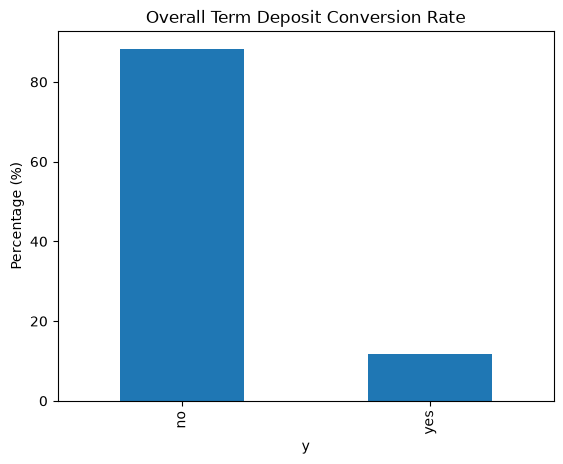

<Figure size 640x480 with 0 Axes>

In [83]:
conversion_rate = df['y'].value_counts(normalize=True)*100

conversion_rate.plot(kind='bar')

plt.ylabel('Percentage (%)')
plt.title('Overall Term Deposit Conversion Rate')
plt.show()
plt.savefig("../images/overall_conversion.png", bbox_inches="tight", dpi=150)
plt.show()

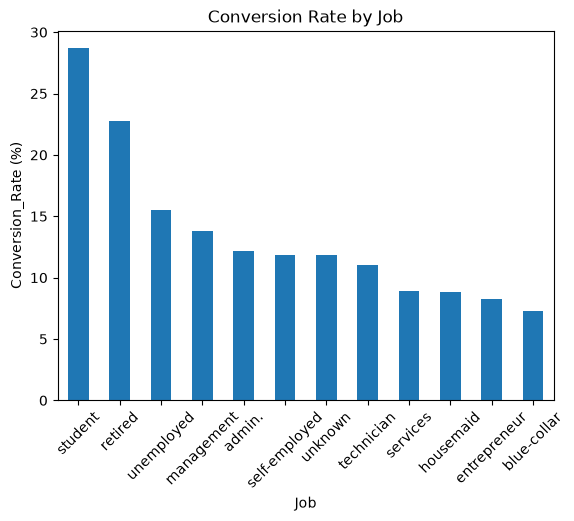

<Figure size 640x480 with 0 Axes>

In [84]:
job_summary['conversion_rate']
job_plot = job_summary.sort_values(
    'conversion_rate',
    ascending=False
)
job_plot['conversion_rate'].plot(kind='bar')
 
plt.ylabel('Conversion_Rate (%)')
plt.xlabel('Job')
plt.title('Conversion Rate by Job')
plt.xticks(rotation=45)
plt.show()
plt.savefig("../images/job_conversion.png", bbox_inches="tight", dpi=150)
plt.show()

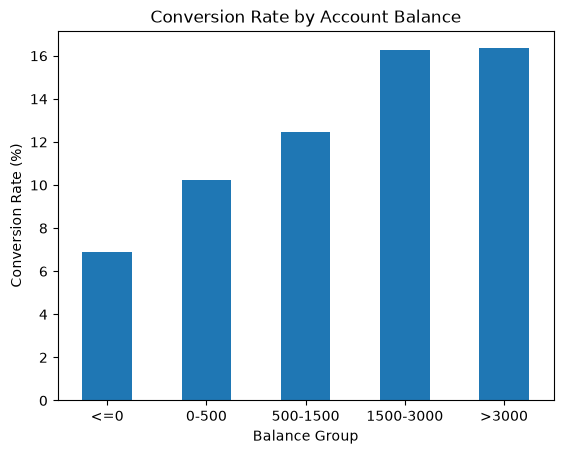

<Figure size 640x480 with 0 Axes>

In [85]:
balance_summary ['conversion_rate'].plot(kind='bar')

plt.ylabel('Conversion Rate (%)')
plt.xlabel('Balance Group')
plt.title('Conversion Rate by Account Balance')
plt.xticks(rotation = 0)
plt.show()
plt.savefig("../images/balance_conversion.png", bbox_inches="tight", dpi=150)
plt.show()

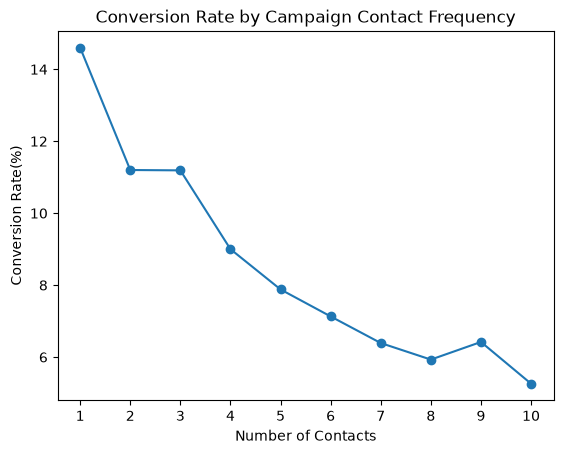

<Figure size 640x480 with 0 Axes>

In [86]:
campaign_plot = campaign_summary.loc[1:10]

campaign_plot['conversion_rate'].plot(
    kind = 'line',
    marker = 'o'
)

plt.xlabel('Number of Contacts')
plt.ylabel('Conversion Rate(%)')
plt.title('Conversion Rate by Campaign Contact Frequency')
plt.xticks(range(1,11))
plt.show()
plt.savefig("../images/campaign_conversion.png", bbox_inches="tight", dpi=150)
plt.show()

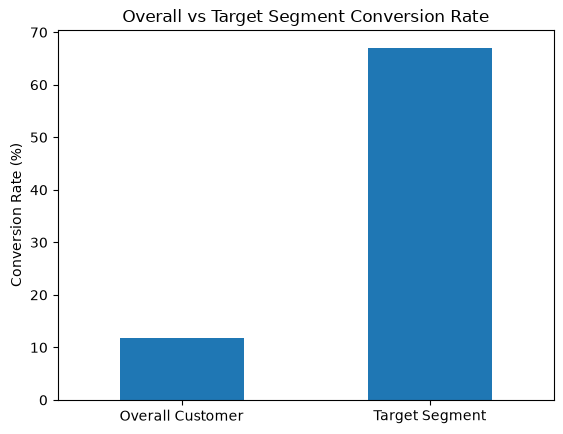

<Figure size 640x480 with 0 Axes>

In [87]:
comparison = pd.Series({
    'Overall Customer' : 11.70,
    'Target Segment' : 67.01
})

comparison.plot(kind = 'bar')

plt.ylabel('Conversion Rate (%)')
plt.title('Overall vs Target Segment Conversion Rate')
plt.xticks(rotation = 0)
plt.show()
plt.savefig("../images/target_conversion.png", bbox_inches="tight", dpi=150)
plt.show()

## 目标客户群体效果对比
整体客户的定期存款转化率约为11.7%，而基于账户余额，贷款状态和历史营销结果筛选出的高潜客户群体转化率约为67.01%

该结果表明，将客户财务特征与历史营销行为结合进行客户细分，有助于识别具有更高转化倾向的目标客户群体

## 7. Business Recommendations

### 1. 优先触达高潜客户群体
优先考虑账户余额较高、无住房贷款、无个人贷款，并且历史营销结果为 success 的客户。
在本数据中，该目标群体的转化率约为 67.01%，明显高于整体约 11.70% 的转化率。

### 2. 控制重复联系频率
在样本量较充足的 1–5 次联系范围内，随着本轮联系次数增加，转化率整体下降。
因此，不建议简单通过增加重复联系次数来提升转化，更适合将资源集中在高潜客户的早期触达。

### 3. 将历史营销结果作为重要 CRM 信号
历史营销结果为 success 的客户，本次转化率明显高于历史 failure 客户。
因此，客户过去的营销响应记录可以作为后续客户优先级排序的重要参考变量。

### 4. 采用分层客户策略
对于 management 等规模较大且转化表现较好的客户群，可以作为核心营销池；
对于 retired、student 等规模较小但转化率较高的群体，可以采用更加精准的定向营销策略。

